In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.font_manager as fm


In [2]:
#폰트 확인

for f in fm.fontManager.ttflist:
  name = f.name
  if any(k in name for k in ['Gothic', 'Malgun', 'Nanum', 'Apple', 'Batang', 'Gulim']):
      print(name)

#나눔고딕 폰트로 그래프 폰트 변경(한글 깨짐 방지)
fm._load_fontmanager(try_read_cache=False)
plt.rc("font", family="NanumGothic")
plt.rc("axes", unicode_minus=False)

MBatang
Showcard Gothic
Copperplate Gothic Bold
Malgun Gothic
Franklin Gothic Heavy
NanumGothic
Yu Gothic
Yu Gothic UI
Yu Gothic UI
Yu Gothic UI Semibold
Franklin Gothic Medium
Century Gothic
Franklin Gothic Demi Cond
Century Gothic
Franklin Gothic Medium Cond
Franklin Gothic Demi
Franklin Gothic Medium
NanumGothic
HCR Batang
New Gulim
HCR Batang ExtB
Copperplate Gothic Light
Franklin Gothic Demi
Yu Gothic
Yu Gothic Light
Yu Gothic UI
Yu Gothic UI Light
Franklin Gothic Book
Malgun Gothic
NanumGothic
NanumGothicExtraBold
HYGothic-Extra
Gulim
GulimChe
Batang
BatangChe
Franklin Gothic Book
Yu Gothic
Yu Gothic UI
Yu Gothic UI Semilight
MJemokBatang
HCR Batang
Franklin Gothic Heavy
Malgun Gothic
Malgun Gothic Semilight
Yu Gothic
Yu Gothic Medium
Yu Gothic UI
MJemokGothic
HCR Batang Ext
HYGothic-Medium
Century Gothic
Century Gothic
HCR Batang ExtB
MS Gothic
MS UI Gothic
MS PGothic


In [26]:
df = pd.read_csv('가스_인구_기온_통합.csv',encoding='cp949')
df

,연월,시도,월평균기온,월평균최고기온,월평균최저기온,가구수(개),공급량(㎥),총인구수
0,2021-01,강원,-4.2,1.5,-9.7,386599,51918.194190,1541696
1,2021-02,강원,1.3,7.3,-4.6,387774,43068.962620,1540875
2,2021-03,강원,7.0,13.3,1.3,388403,32782.803000,1536399
3,2021-04,강원,11.8,17.9,5.7,390610,20762.350470,1536175
4,2021-05,강원,15.3,21.1,10.0,391098,14472.110240,1535491
...,...,...,...,...,...,...,...,...
1183,2026-02,충북,1.1,7.7,-5.0,584666,47598.860310,1596816
1184,2026-03,충북,6.8,13.6,0.5,579452,39099.270910,1597976
1185,2026-04,충북,13.5,20.6,6.4,576171,21893.604080,1599375
1186,2026-05,충북,18.6,25.5,11.8,576065,12157.524940,1600216


In [27]:
#결측치 유무 판단
df.isnull().sum()

연월         0
시도         0
월평균기온      0
월평균최고기온    0
월평균최저기온    0
가구수(개)     0
공급량(㎥)     0
총인구수       0
dtype: int64

In [28]:
#각 열에 대한 식별자를 판단
len(df) #전체 데이터의 갯수
df.nunique()   #unique 고유한 값의 갯수 파악 => 전체 데이터의 갯수와 비슷하다? = 식별자

#df.nunique() / len(df) 로 유일값 비율 계산 → 1에 가까우면 식별자.
unique_rate = df.nunique() / len(df)
print(unique_rate.sort_values(ascending=False))

총인구수       0.999158
공급량(㎥)     0.998316
가구수(개)     0.997475
월평균최저기온    0.281987
월평균최고기온    0.259259
월평균기온      0.253367
연월         0.055556
시도         0.015152
dtype: float64


In [29]:
#시각화(차트)를 위한 라이브러리 설치
!pip install matplotlib seaborn scipy

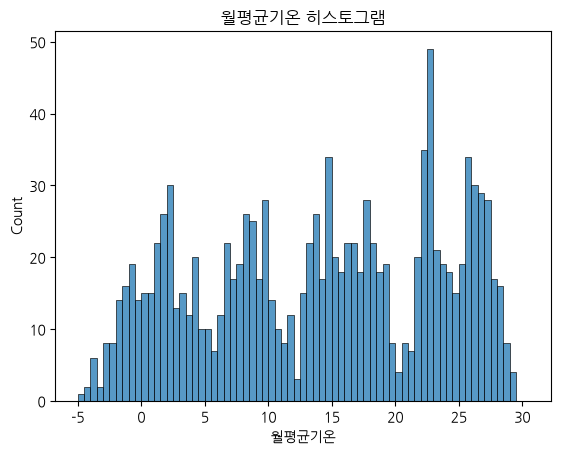

In [30]:
#히스토그램으로 가스공급량 데이터의 분포를 확인
import numpy as np
sns.histplot(df['월평균기온'], bins=np.arange(-5, 31, 0.5))
plt.title('월평균기온 히스토그램')
plt.show()

In [31]:
df['월평균기온'].max()      #29.3
df['월평균기온'].min()      #-4.8
df['월평균최고기온'].max()   #34.4
df['월평균최저기온'].min()   #-10.3

np.float64(-10.3)

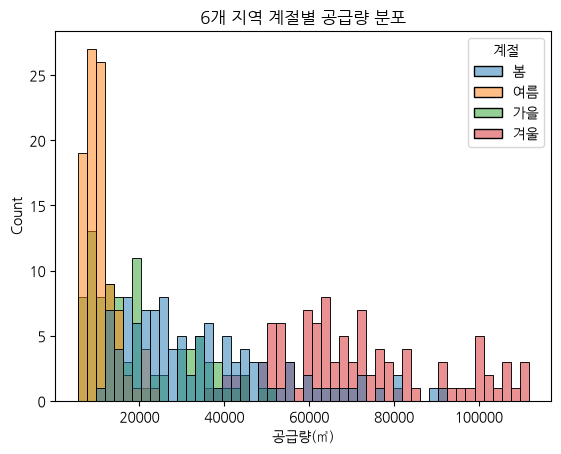

In [ ]:
#월을 계절로 매핑 함수 정의
def get_season(m) : 
  if m in [3,4,5] : return '봄'
  elif m in [6,7,8] : return '여름'
  elif m in [9,10,11] : return '가을'
  else :  return '겨울'

#지역별 데이터 정리
target = ['전북','대전','경남','경북','광주','강원']
filtered_df = df[df['시도'].isin(target)].copy()

#컬럼에서 month 추출 후 계절 이름 매핑
filtered_df['월'] = pd.to_datetime(filtered_df['연월']).dt.month
filtered_df['계절'] = filtered_df['월'].apply(get_season)

sns.histplot(
  data=filtered_df,
  x='공급량(㎥)',
  hue='계절',
  bins=50,
  hue_order=['봄', '여름', '가을', '겨울']
)

plt.title('6개 지역 계절별 공급량 분포')
plt.show()

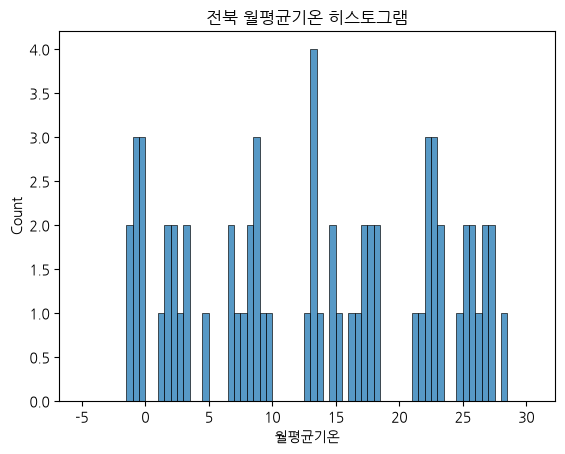

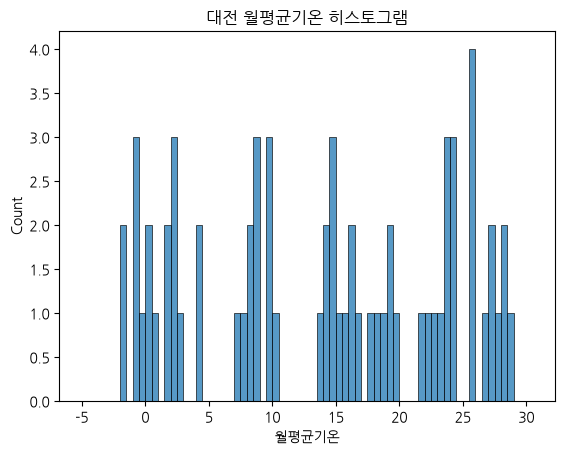

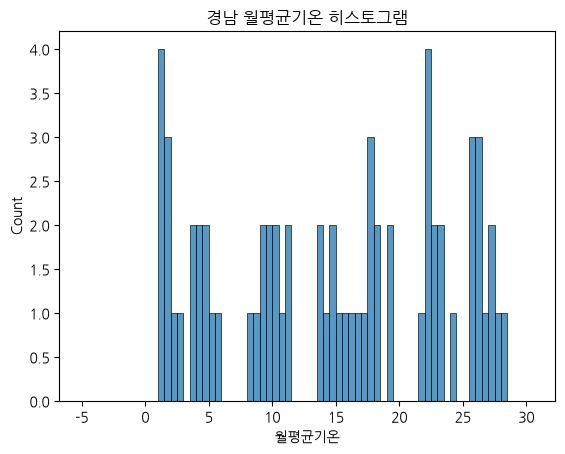

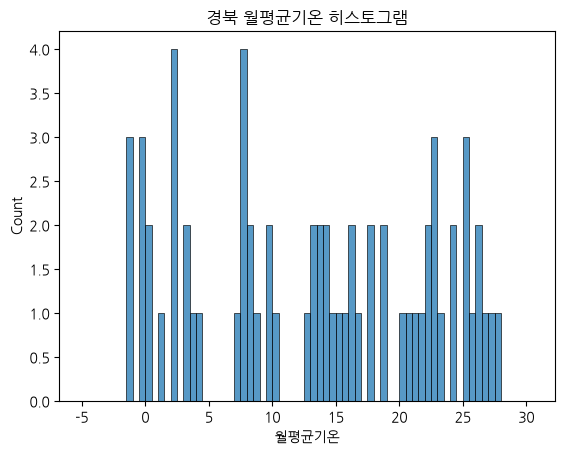

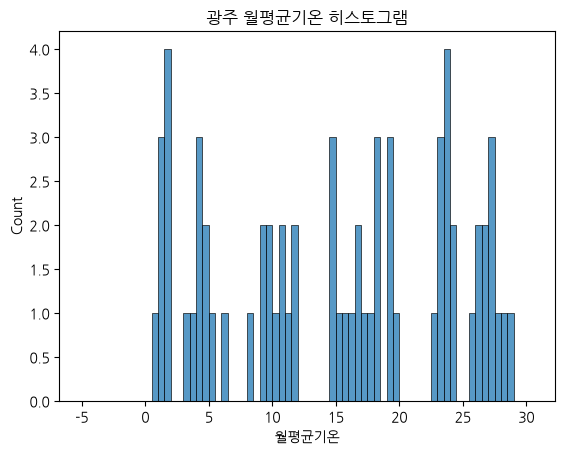

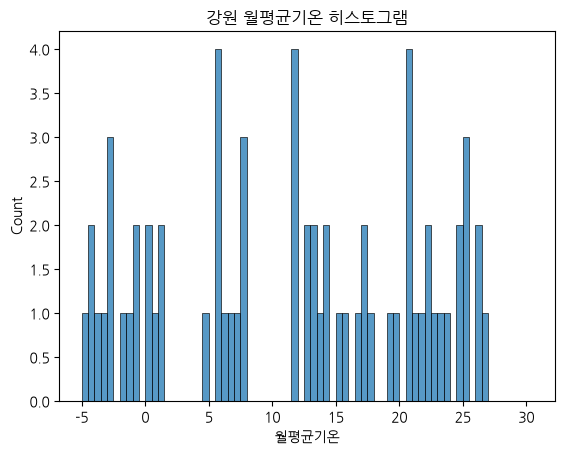

In [35]:
regions = ['전북','대전','경남','경북','광주','강원']

for region in regions : 
  data = filtered_df[filtered_df['시도'] == region]
  sns.histplot(data['월평균기온'], bins=np.arange(-5, 31, 0.5))
  plt.title(f'{region} 월평균기온 히스토그램')
  plt.show()

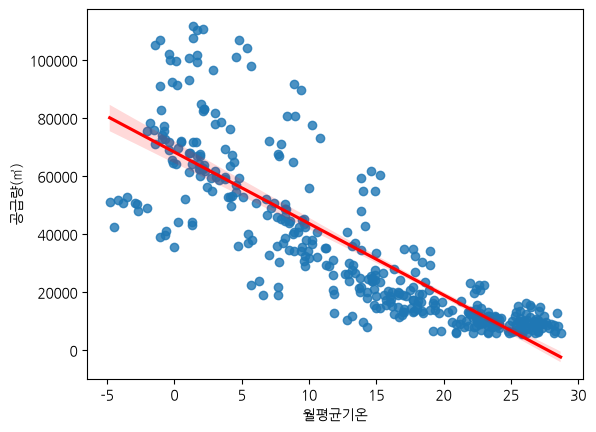

Pearson  상관계수:  -0.841,  p-value:  0.0000
Spearman  상관계수:  -0.895,  p-value:  0.0000


In [39]:
#  추세선까지  추가하면  관계  판단이  쉬움
sns.regplot(x='월평균기온',  y='공급량(㎥)',  data=filtered_df, line_kws={'color':  'red'})
plt.show()

from  scipy.stats  import  pearsonr,  spearmanr
r,  p  =  pearsonr(filtered_df['월평균기온'],  filtered_df['공급량(㎥)'])
print(f"Pearson  상관계수:  {r:.3f},  p-value:  {p:.4f}")
r_s,  p_s  =  spearmanr(filtered_df['월평균기온'],  filtered_df['공급량(㎥)']) 
print(f"Spearman  상관계수:  {r_s:.3f},  p-value:  {p_s:.4f}")